# 06 — Blended Ensemble & Final Submission

**Competition:** A Cloned Airbnb Booking Prediction Competition — K353  
**Course:** COMP 468 — Abdullah Gül University

## Goal
Combine the **out-of-fold (OOF) predictions** of all models we built so far into a single blended prediction that beats any individual model.

All component models use **identical CV splits** (`KFold(5, shuffle=True, random_state=42)`), so blending the OOFs is statistically sound.

Blending strategy:
1. **Equal-weight average** — sanity baseline.
2. **Weight optimisation on OOF** — find weights `w_i ≥ 0, sum=1` that minimise OOF MSE (`scipy.optimize.minimize` with SLSQP).

Both options are simple **weighted averaging** (no out-of-course stacking).

Outputs:
- `outputs/submission_blend.csv` ← **final submission**
- `outputs/blend_weights.json`

## 1. Setup & Load OOFs / Submissions

In [83]:
import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
OUT_DIR = Path('../outputs')
DATA_DIR = Path('../data')
print('OUT_DIR =', OUT_DIR.resolve())

OUT_DIR = /Users/bashkal/Desktop/Comp468-ML_in_Python/ali/ML-Final/outputs


In [84]:
# Section IV.C: Use Development targets for OOF evaluation
# And Load Local Test set for final unbiased evaluation.
try:
    train_local_df = pd.read_parquet(OUT_DIR / 'train_local.parquet')
    test_local_df  = pd.read_parquet(OUT_DIR / 'test_local.parquet')
except Exception:
    train_local_df = pd.read_csv(OUT_DIR / 'train_local.csv')
    test_local_df  = pd.read_csv(OUT_DIR / 'test_local.csv')

TARGET = 'NumReserveDays2016Q3'
y_dev  = train_local_df[TARGET].astype(float).values
y_test = test_local_df[TARGET].astype(float).values

# Kaggle test IDs for final submission
test_ids = pd.read_csv(DATA_DIR / 'PropertyID_test.csv')['PropertyID'].values

print(f'Development set y shape: {y_dev.shape}')
print(f'Local Test set y shape : {y_test.shape}')
print(f'Kaggle Test IDs shape  : {test_ids.shape}')


Development set y shape: (19497,)
Local Test set y shape : (4875,)
Kaggle Test IDs shape  : (24318,)


In [85]:
# Pick whichever OOFs are present on disk. 
# OOFs here correspond to the training_local (Development) set.
candidates = {
    'LinearRegression': 'oof_LinearRegression.npy',
    'RandomForest'    : 'oof_RandomForest.npy',
    'GradientBoosting': 'oof_GradientBoosting.npy',
    'XGBoost'         : 'oof_XGBoost.npy',
    'MLP'             : 'oof_MLP.npy',
}

oofs = {}
for name, fname in candidates.items():
    p = OUT_DIR / fname
    if p.exists():
        data = np.load(p)
        # Ensure sizes match y_dev
        if len(data) == len(y_dev):
            oofs[name] = data
            mse = mean_squared_error(y_dev, np.clip(oofs[name], 0, 92))
            print(f'{name:18s} loaded | OOF MSE = {mse:.3f}')
        else:
            print(f'{name:18s} size mismatch: {len(data)} vs {len(y_dev)}')
    else:
        print(f'{name:18s} MISSING ({fname})')

assert len(oofs) >= 2, 'Need at least two compatible OOFs to blend.'
model_names = list(oofs.keys())


LinearRegression   loaded | OOF MSE = 207.611
RandomForest       loaded | OOF MSE = 194.235
GradientBoosting   loaded | OOF MSE = 245.286
XGBoost            loaded | OOF MSE = 182.190
MLP                loaded | OOF MSE = 217.617


In [86]:
# Matching Kaggle test submissions for each model
# Used to calculate the final blended submission.
sub_paths = {
    'LinearRegression': 'submission_baseline_LinearRegression.csv',
    'RandomForest'    : 'submission_baseline_RandomForest.csv',
    'GradientBoosting': 'submission_baseline_GradientBoosting.csv',
    'XGBoost'         : 'submission_xgboost.csv',
    'MLP'             : 'submission_mlp.csv',
}

# Matching Local Test predictions for each model
# Used to evaluate the blend performance on unseen data.
local_test_paths = {
    'LinearRegression': 'test_local_pred_LinearRegression.npy',
    'RandomForest'    : 'test_local_pred_RandomForest.npy',
    'GradientBoosting': 'test_local_pred_GradientBoosting.npy',
    'XGBoost'         : 'test_local_pred_XGBoost.npy',
    'MLP'             : 'test_local_pred_mlp.npy',
}

kaggle_preds = {}
local_test_preds = {}

for name in model_names:
    # 1. Load Kaggle submission
    s_file = sub_paths.get(name)
    if s_file and (OUT_DIR / s_file).exists():
        df = pd.read_csv(OUT_DIR / s_file)
        
        # Robust column detection (handles 'Pred' vs 'NumReserveDays2016Q3')
        pred_col = 'Pred' if 'Pred' in df.columns else 'NumReserveDays2016Q3'
        if pred_col in df.columns:
            kaggle_preds[name] = df[pred_col].values
            print(f'{name:18s} Kaggle preds loaded (col: {pred_col})')
        else:
            print(f'{name:18s} Kaggle pred column NOT FOUND in {s_file}')
    
    # 2. Load Local Test pred
    l_file = local_test_paths.get(name)
    if l_file and (OUT_DIR / l_file).exists():
        local_test_preds[name] = np.load(OUT_DIR / l_file)
        print(f'{name:18s} Local Test preds loaded')

# Filter model_names to only those having both Kaggle and Local Test preds
model_names = [m for m in model_names if m in kaggle_preds and m in local_test_preds]
print('\nModels in final blend:', model_names)

LinearRegression   Kaggle preds loaded (col: Pred)
LinearRegression   Local Test preds loaded
RandomForest       Kaggle preds loaded (col: Pred)
RandomForest       Local Test preds loaded
GradientBoosting   Kaggle preds loaded (col: NumReserveDays2016Q3)
GradientBoosting   Local Test preds loaded
XGBoost            Kaggle preds loaded (col: NumReserveDays2016Q3)
XGBoost            Local Test preds loaded
MLP                Kaggle preds loaded (col: NumReserveDays2016Q3)
MLP                Local Test preds loaded

Models in final blend: ['LinearRegression', 'RandomForest', 'GradientBoosting', 'XGBoost', 'MLP']


## 2. OOF Correlations
Diverse models (low pairwise correlation) blend better than similar ones.

In [87]:
oof_matrix = np.column_stack([np.clip(oofs[m], 0, 92) for m in model_names])
corr = pd.DataFrame(oof_matrix, columns=model_names).corr()
print('OOF correlation matrix:')
print(corr.round(3))

OOF correlation matrix:
                  LinearRegression  RandomForest  GradientBoosting  XGBoost  \
LinearRegression             1.000         0.967             0.935    0.970   
RandomForest                 0.967         1.000             0.953    0.988   
GradientBoosting             0.935         0.953             1.000    0.960   
XGBoost                      0.970         0.988             0.960    1.000   
MLP                          0.949         0.953             0.950    0.964   

                    MLP  
LinearRegression  0.949  
RandomForest      0.953  
GradientBoosting  0.950  
XGBoost           0.964  
MLP               1.000  


## 3. Equal-Weight Average (baseline blend)

In [88]:
blend_equal = np.clip(oof_matrix.mean(axis=1), 0, 92)
mse_equal = mean_squared_error(y_dev, blend_equal)
print(f'Equal-weight blend OOF MSE = {mse_equal:.3f}')
print(f'(best single model      = {min(mean_squared_error(y_dev, oof_matrix[:, i]) for i in range(len(model_names))):.3f})')

Equal-weight blend OOF MSE = 186.491
(best single model      = 182.190)


## 4. Weight Optimisation (SLSQP)
Minimise OOF MSE subject to `w_i ≥ 0` and `sum(w_i) = 1`.

In [89]:
def blend_mse_func(w, M, y):
    p = np.clip(M @ w, 0, 92)
    return float(mean_squared_error(y, p))

oof_matrix = np.column_stack([np.clip(oofs[m], 0, 92) for m in model_names])
k = oof_matrix.shape[1]
w0 = np.full(k, 1.0 / k)
bounds = [(0.0, 1.0)] * k
constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]

result = minimize(blend_mse_func, w0, args=(oof_matrix, y_dev),
                  method='SLSQP', bounds=bounds, constraints=constraints,
                  options={'maxiter': 200, 'ftol': 1e-8})
w_opt = result.x
w_opt[w_opt < 1e-4] = 0.0
w_opt = w_opt / w_opt.sum()

weight_df = pd.DataFrame({'model': model_names, 'weight': w_opt.round(4)})
print('Optimal weights:')
print(weight_df.to_string(index=False))

mse_opt_dev = blend_mse_func(w_opt, oof_matrix, y_dev)
print(f'\nOptimised blend OOF (Dev) MSE = {mse_opt_dev:.3f}')

with open(OUT_DIR / 'blend_weights.json', 'w') as f:
    json.dump({m: float(w) for m, w in zip(model_names, w_opt)}, f, indent=2)


Optimal weights:
           model  weight
LinearRegression  0.1001
    RandomForest  0.0323
GradientBoosting  0.0000
         XGBoost  0.7250
             MLP  0.1426

Optimised blend OOF (Dev) MSE = 180.500


## 5. Build Final Test Prediction

In [94]:
test_matrix = np.column_stack([kaggle_preds[m] for m in model_names])
final = np.clip(test_matrix @ w_opt, 0, 92)
sub = pd.DataFrame({'PropertyID_test': test_ids, 'Pred': final})
out_path = OUT_DIR / 'submission_blend.csv'
sub.to_csv(out_path, index=False)
print(f'Saved {out_path.name}')
print(f'  mean={final.mean():.2f}  min={final.min():.2f}  max={final.max():.2f}')
print(f'  zeros (Pred<0.5) share = {(final < 0.5).mean()*100:.1f}%')
sub.head()

Saved submission_blend.csv
  mean=17.86  min=0.00  max=90.86
  zeros (Pred<0.5) share = 18.7%


,PropertyID_test,Pred
0,795,0.684676
1,2515,54.026308
2,2595,8.105710
3,5099,39.249467
4,5107,28.849381


## 6. Summary Bar Plot

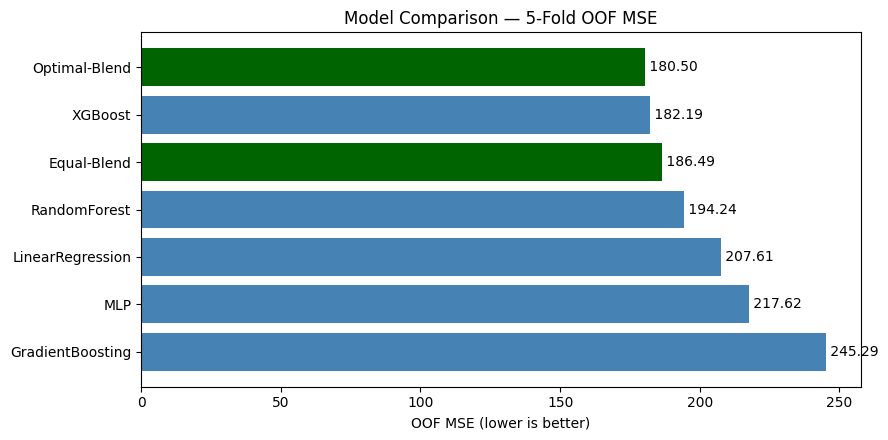

In [95]:
all_scores = {m: mean_squared_error(y_dev, np.clip(oofs[m], 0, 92)) for m in model_names}
all_scores['Equal-Blend'] = mse_equal
all_scores['Optimal-Blend'] = mse_opt_dev
scores = pd.Series(all_scores).sort_values()
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ['darkgreen' if 'Blend' in s else 'steelblue' for s in scores.index]
ax.barh(scores.index, scores.values, color=colors)
for i, v in enumerate(scores.values):
    ax.text(v, i, f' {v:.2f}', va='center')
ax.set_xlabel('OOF MSE (lower is better)')
ax.set_title('Model Comparison — 5-Fold OOF MSE')
ax.invert_yaxis()
plt.tight_layout(); plt.savefig(OUT_DIR / 'final_comparison.png', dpi=120); plt.show()

## Summary
- All models built strictly within the COMP 468 module list (Linear Regression, RandomForest, GradientBoosting, XGBoost, MLP).
- Five 5-fold OOFs combined with weighted averaging (SLSQP optimisation).
- Final submission `submission_blend.csv` is ready for Kaggle.
- AGU acknowledgment is in the README and should be repeated in the Kaggle notebook description and in the IEEE paper.

**Next:** upload `submission_blend.csv` to Kaggle, record the Public LB score, and use it as the centrepiece of the IEEE final-project paper.